In [1]:
import utils
import numpy as np
import pandas as pd
import os
import re
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [2]:
# Preparation
plot_range = [0, 6]
dataset = 'pilot' # TUS, joystick, speakup, africa
split_dataset = False

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if dataset == 'TUS' or dataset == 'joystick':
    raw_output_path = '/Volumes/project/3025011.02/raw'
    unique_subject_ids = [52, 53, 54, 55, 57]
    unique_sessions = [2, 3, 4]
elif dataset == 'pilot':
    raw_output_path = '/Volumes/project/3025011.02/long_experiment_data/phd_1_task/experiment_output'
    unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]
    unique_sessions = [2, 3, 4]
elif dataset=='speakup':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/190526/raw'
    unique_subject_ids = [2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53]
    unique_sessions = [3]
elif dataset=='africa':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/RL_task-speakup_version_martin_southafrica/experiment_output'
    unique_subject_ids = [2, 3, 4, 5, 6, 8, 9, 10, 12, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    unique_sessions = [1]

# Make output folder
output_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/{dataset}/behavioural/objective_performance'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, dataset, remove_reversals=False) # Remove reversals since those don't tell us anything about their performance. Only useful for RT analyses

These participants will be excluded: {'sub-011_session-03', 'sub-011_session-04', 'sub-011_session-02', 'sub-011_session-01', 'sub-016_session-04'}



In [3]:
# Multiply some variables by 100 to show percentage correct etc
combined_results_dataframe['objectively_correct_boolean'] = combined_results_dataframe['objectively_correct_boolean'] * 100
mapping = {-1: 0, 1: 1}
combined_results_dataframe['response_boolean'] = combined_results_dataframe['response_boolean'].map(mapping)
combined_results_dataframe['response_boolean'] = combined_results_dataframe['response_boolean'].astype('Int64')
combined_results_dataframe_shortened = combined_results_dataframe[combined_results_dataframe['trials_since_reversal_separate_learning']<=5]

# Sanity checks

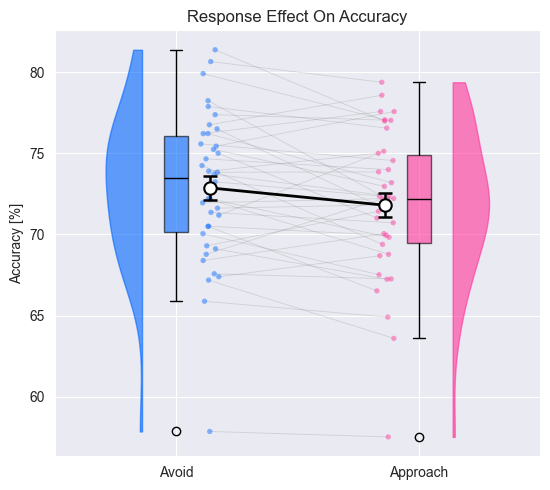

In [4]:
# Check for a response bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns='response',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['avoid','approach'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='accuracy [%]',
    plot_name='response effect on accuracy'
);

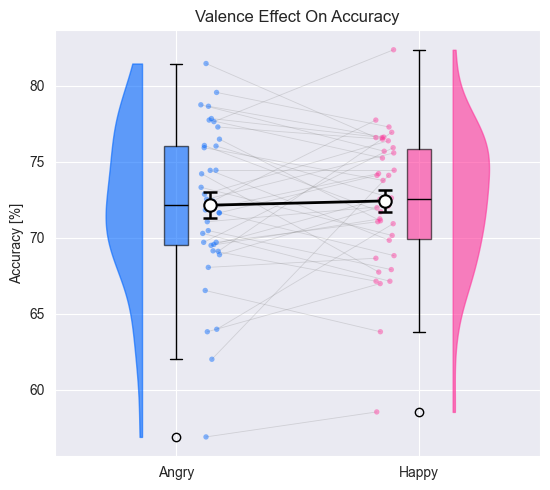

In [5]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns='valence',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['angry', 'happy'],
    labels=['Angry', 'Happy'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='accuracy [%]',
    plot_name='valence effect on accuracy'
);

# Average performance over time

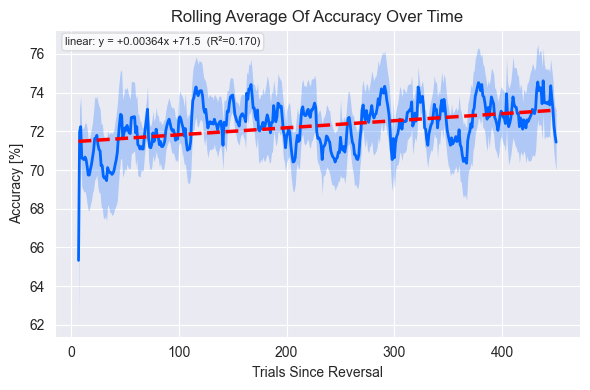

In [6]:
combined_results_dataframe['objectively_correct_rolling_average'] = combined_results_dataframe['objectively_correct_boolean'].rolling(window=40).mean()

utils.plotting_functions.lineplot_se(
    df=combined_results_dataframe,
    x_col='trial', y_col='objectively_correct_rolling_average',
    xlabel_name='trials since reversal', ylabel_name='accuracy [%]',
    subject_col='subject_id',
    output_dir=output_dir,
    legend_outside=True,
    trend=['linear'], show_trend_stats=True, trend_colour='red',
    plot_name='rolling average of accuracy over time'
);

# Actual analysis

## Congruency

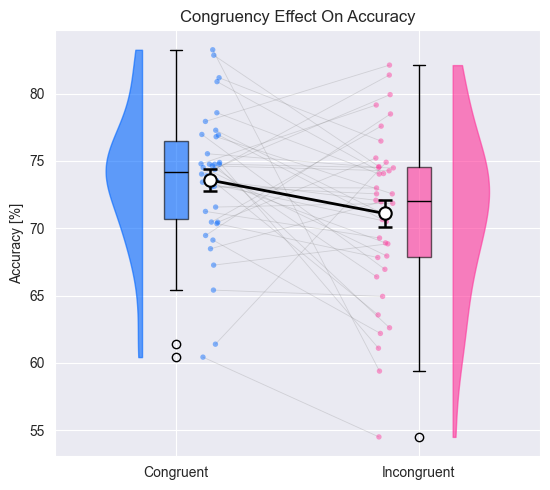

In [7]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['congruent','incongruent'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='accuracy [%]',
    plot_name='congruency effect on accuracy'
);

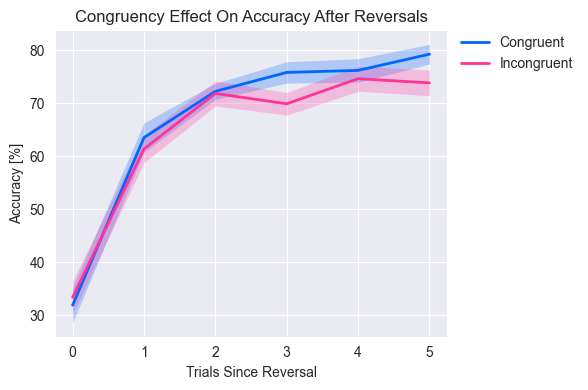

In [8]:
utils.plotting_functions.lineplot_se(
    df=combined_results_dataframe_shortened,
    x_col='trials_since_reversal_separate_learning', y_col='objectively_correct_boolean',
    xlabel_name='trials since reversal', ylabel_name='accuracy [%]',
    subject_col='subject_id', condition_col='congruency',
    output_dir=output_dir,
    legend_outside=True,
    plot_name='congruency effect on accuracy after reversals'
);

## Volatility

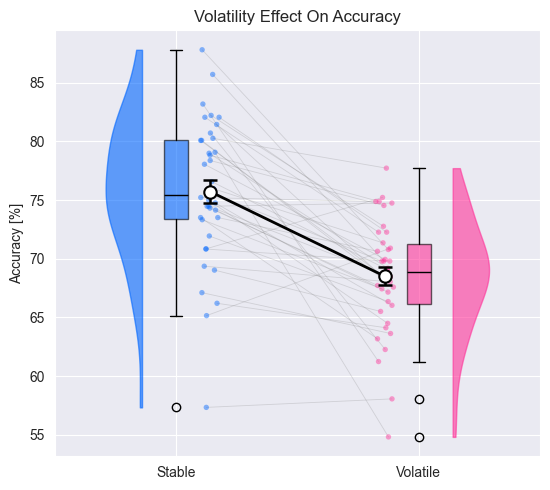

In [9]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id', 'session'],
            columns='volatility',
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable','volatile'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='volatility effect on accuracy'
    );

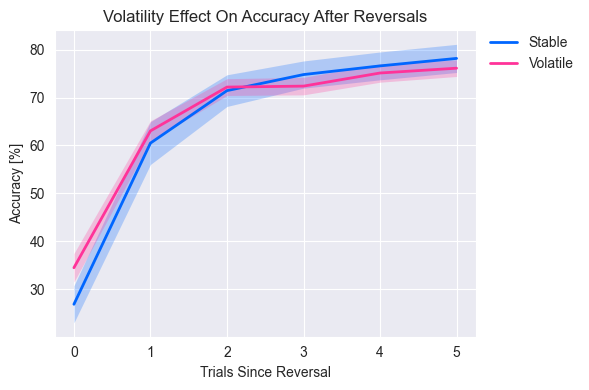

In [10]:
if dataset!='africa':
    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened,
        x_col='trials_since_reversal_separate_learning', y_col='objectively_correct_boolean',
        xlabel_name='trials since reversal', ylabel_name='accuracy [%]',
        subject_col='subject_id', condition_col='volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='volatility effect on accuracy after reversals'
    );

## Congruency split into response and valence

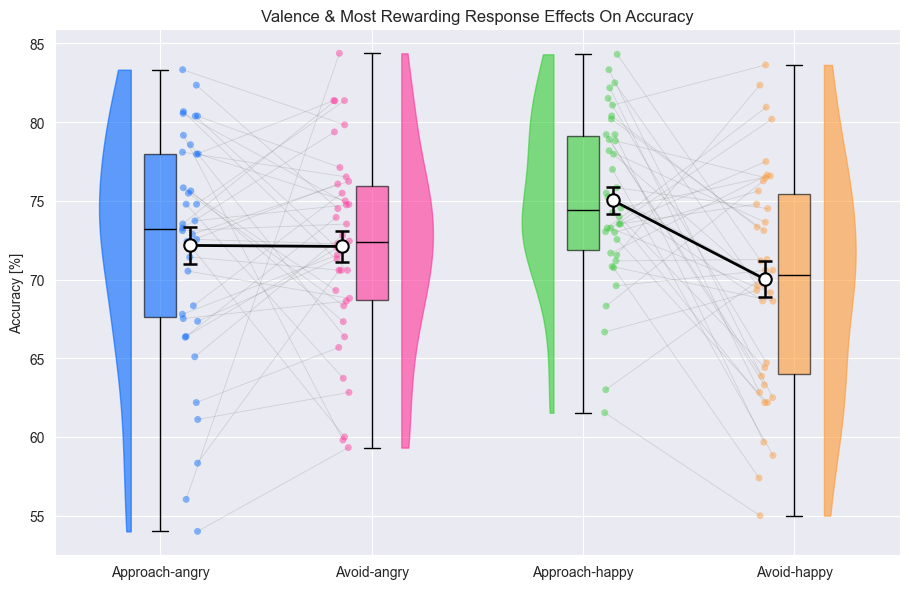

In [11]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['valence', 'most_rewarding_response'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    '_'.join(str(x) for x in col if x)
    for col in combined_results_pivoted.columns
]

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['angry_approach','angry_avoid','happy_approach','happy_avoid'],
    labels=['approach-angry','avoid-angry','approach-happy','avoid-happy'],
    flip=['left','right','left','right'],
    connect_pairs=[(0, 1), (2, 3)],
    output_dir=output_dir,
    ylabel_name='accuracy [%]',
    plot_name='valence & most rewarding response effects on accuracy'
);

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3679/1121479991.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_shortened['response_valence'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str)


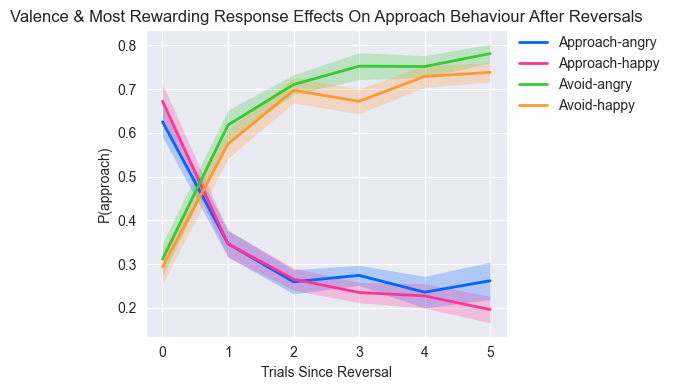

In [12]:
combined_results_dataframe_shortened['response_valence'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str)

utils.plotting_functions.lineplot_se(
    df=combined_results_dataframe_shortened,
    x_col='trials_since_reversal_separate_learning', y_col='response_boolean',
    xlabel_name='trials since reversal', ylabel_name='p(approach)',
    labels=['approach-angry','approach-happy','avoid-angry','avoid-happy'],
    subject_col='subject_id', condition_col='response_valence',
    output_dir=output_dir,
    legend_outside=True,
    plot_name='valence & most rewarding response effects on approach behaviour after reversals'
);

## Congruency split into valence and response, further split by volatility

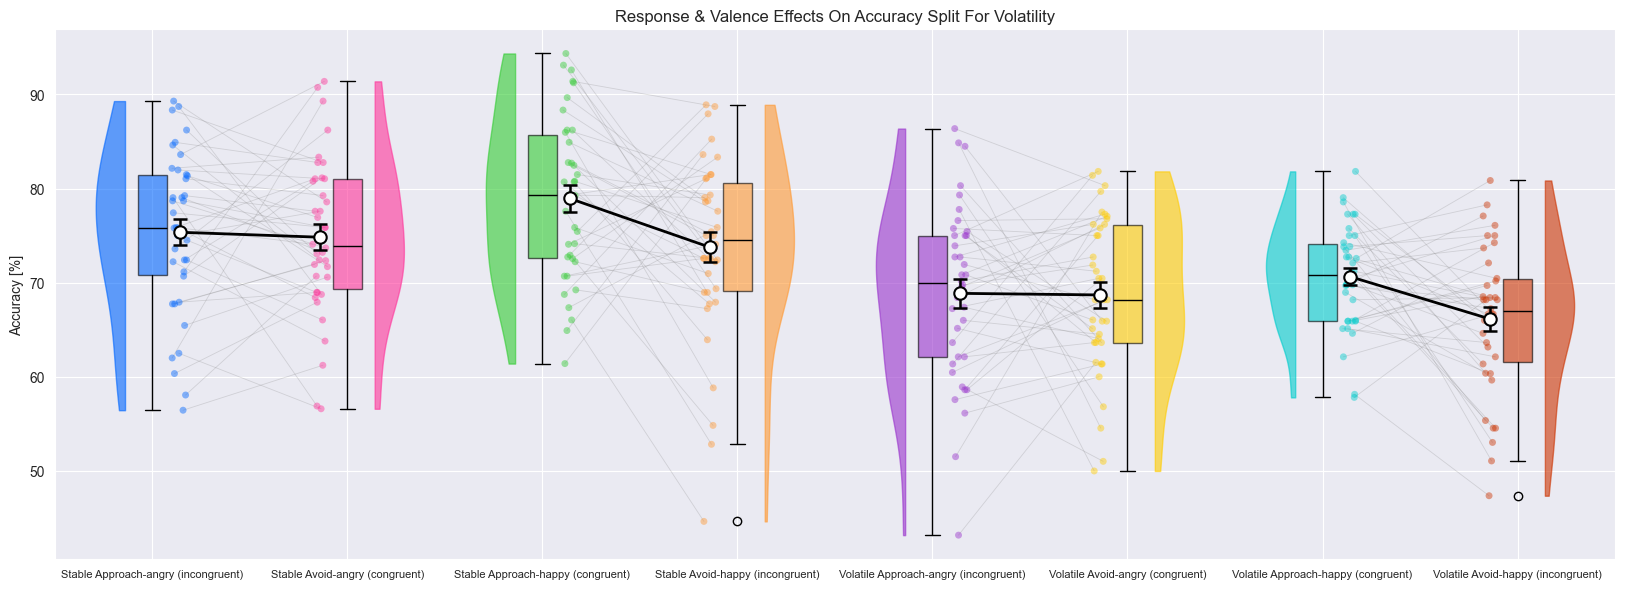

In [13]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['volatility', 'valence', 'most_rewarding_response'],
            values='objectively_correct_boolean',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_angry_approach','stable_angry_avoid','stable_happy_approach','stable_happy_avoid','volatile_angry_approach','volatile_angry_avoid','volatile_happy_approach','volatile_happy_avoid'],
        labels=['stable approach-angry (incongruent)','stable avoid-angry (congruent)','stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='accuracy [%]',
        plot_name='response & valence effects on accuracy split for volatility'
    );

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_3679/1739390629.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_shortened['response_valence_volatility'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str) + '_' + combined_results_dataframe_shortened['volatility'].astype(str)


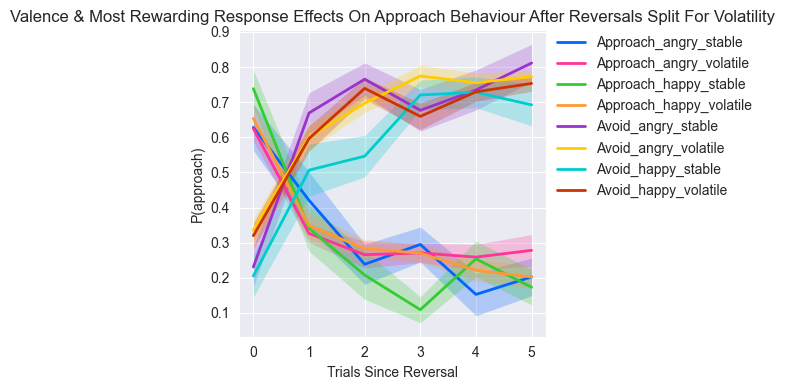

In [14]:
if dataset!='africa':
    combined_results_dataframe_shortened['response_valence_volatility'] = combined_results_dataframe_shortened['most_rewarding_response'].astype(str) + '_' + combined_results_dataframe_shortened['valence'].astype(str) + '_' + combined_results_dataframe_shortened['volatility'].astype(str)

    utils.plotting_functions.lineplot_se(
        df=combined_results_dataframe_shortened,
        x_col='trials_since_reversal_separate_learning', y_col='response_boolean',
        xlabel_name='trials since reversal', ylabel_name='p(approach)',
        subject_col='subject_id', condition_col='response_valence_volatility',
        output_dir=output_dir,
        legend_outside=True,
        plot_name='valence & most rewarding response effects on approach behaviour after reversals split for volatility'
    );